In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.datasets import make_classification 
from sklearn.utils import resample 
from collections import Counter

In [5]:
pip install collection


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for collection: filename=collection-0.1.6-py3-none-any.whl size=5111 sha256=9e2ff807a727b8739e252589907bcda114f7b38a35663edacdfe1d4de7b9a9e4
  Stored in directory: c:\users\hp\appdata\local\pip\cache\wheels\12\bb\2e\e430efbb8e7a845a40292527c78c51d201db424b763ae2ccdb
Successfully built collection


Original Class Distribution: Counter({0: 894, 1: 106})


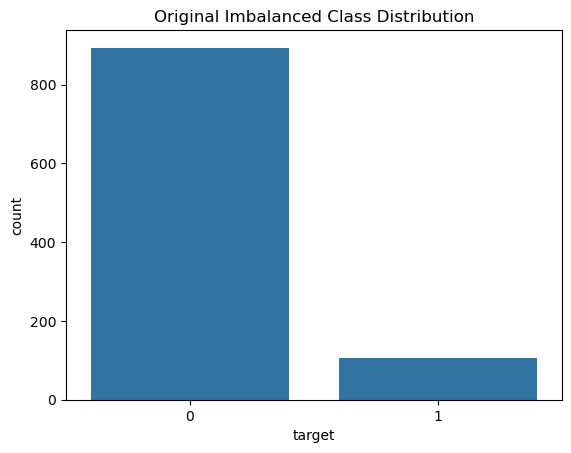

In [6]:
x,y = make_classification(n_classes = 2 , class_sep = 2 , weights = [0.9,0.1],n_informative = 3, n_redundant = 0, n_features = 5, n_samples = 1000, random_state = 42)
df = pd.DataFrame(x,columns =[f"feature_{i}" for i in range(x.shape[1])])
df['target']= y
print("Original Class Distribution:", Counter(y))
sns.countplot(x=df['target'])
plt.title("Original Imbalanced Class Distribution")
plt.show()

In [7]:
# oversampling method

In [8]:
df_majority = df[df['target']==0]
df_minority = df[df['target']==1]

df_minority_oversampled = resample(df_minority,replace = True, n_samples = len(df_majority) , random_state = 42)

df_over = pd.concat([df_majority, df_minority_oversampled])
print("After oversampling: ",Counter(df_over['target']))

After oversampling:  Counter({0: 894, 1: 894})


In [ ]:
# undersampling method

In [9]:
df_majority_undersample = resample(df_majority,replace = False, n_samples = len(df_minority), random_state = 42)

df_under = pd.concat([df_majority_undersample, df_minority])
print("After Undersampling: ",Counter(df_under['target']))

After Undersampling:  Counter({0: 106, 1: 106})


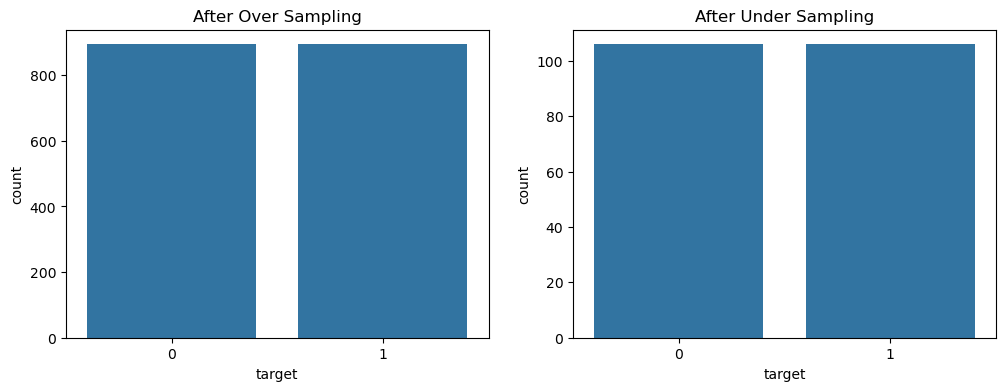

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.countplot(x=df_over['target'], ax = axes[0])
axes[0].set_title("After Over Sampling")


sns.countplot(x=df_under['target'], ax = axes[1])
axes[1].set_title("After Under Sampling")

plt.show()